# EDA WikiArt Dataset — GALERIA
Notebook ini berisi seluruh tahapan EDA sesuai instruksi tugas: data acquisition, data cleaning, labelling review, EDA, dan data splitting.

## 0. Setup & Load Metadata

In [5]:
import os
import stat
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset_builder
from sklearn.model_selection import train_test_split

# lokasi data: telusuri ke atas dari folder kerja sampai ketemu .../data/raw/metadata.csv
def _find_data_raw():
    from pathlib import Path
    here = Path.cwd()
    for base in [here, *here.parents]:
        for rel in ("data/raw", "ml/data/raw"):
            cand = base / rel
            if (cand / "metadata.csv").is_file():
                return str(cand)
    raise FileNotFoundError(f"Folder data/raw (berisi metadata.csv) tak ketemu dari {here}")

output_dir = _find_data_raw()
print("output_dir =", output_dir)
csv_path = os.path.join(output_dir, "metadata.csv")

meta_df = pd.read_csv(csv_path)

# mapping label index -> nama asli, HANYA kalau kolomnya belum ada
# (mencegah proses berulang / error kalau cell ini dijalankan lebih dari sekali)
if 'artist_name' not in meta_df.columns:
    builder = load_dataset_builder("huggan/wikiart")
    features = builder.info.features
    artist_names = features['artist'].names
    genre_names = features['genre'].names
    style_names = features['style'].names

    meta_df['artist_name'] = meta_df['artist'].apply(lambda x: artist_names[x])
    meta_df['genre_name'] = meta_df['genre'].apply(lambda x: genre_names[x])
    meta_df['style_name'] = meta_df['style'].apply(lambda x: style_names[x])

    # pastikan file tidak read-only sebelum ditulis
    if os.path.exists(csv_path):
        try:
            os.chmod(csv_path, stat.S_IWRITE)
        except Exception as e:
            print("Gagal ubah permission:", e)

    # coba simpan ke file asli; kalau gagal (masih permission error),
    # otomatis fallback simpan ke nama file baru supaya proses tidak berhenti
    try:
        meta_df.to_csv(csv_path, index=False)
        print("Berhasil disimpan ke:", csv_path)
    except PermissionError as e:
        fallback_path = os.path.join(output_dir, "metadata_updated.csv")
        meta_df.to_csv(fallback_path, index=False)
        print(f"PermissionError pada '{csv_path}' -> disimpan sebagai fallback ke: {fallback_path}")
        print("Penyebab kemungkinan: file sedang terbuka di Excel/editor lain, atau permission folder bermasalah.")
else:
    print("Kolom nama label sudah ada, tidak perlu diproses ulang.")

meta_df.head()

Kolom nama label sudah ada, tidak perlu diproses ulang.


,filename,artist,genre,style,artist_name,genre_name,style_name
0,wikiart_00000.jpg,22,4,21,vincent-van-gogh,landscape,Realism
1,wikiart_00001.jpg,20,7,4,rembrandt,religious_painting,Baroque
2,wikiart_00002.jpg,16,6,20,paul-cezanne,portrait,Post_Impressionism
3,wikiart_00003.jpg,17,2,12,pierre-auguste-renoir,genre_painting,Impressionism
4,wikiart_00004.jpg,9,10,23,ivan-aivazovsky,Unknown Genre,Romanticism


## 1. Deteksi File Korup, Duplikat, dan Resolusi Kecil

In [6]:
corrupt_files, low_res_files, duplicate_files = [], [], []
hashes = {}
MIN_RESOLUTION = 100

for fname in meta_df['filename']:
    filepath = os.path.join(output_dir, fname)
    try:
        img = Image.open(filepath)
        img.verify()
        img = Image.open(filepath)
    except Exception:
        corrupt_files.append(fname)
        continue

    w, h = img.size
    if w < MIN_RESOLUTION or h < MIN_RESOLUTION:
        low_res_files.append((fname, w, h))

    with open(filepath, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash in hashes:
        duplicate_files.append((fname, hashes[file_hash]))
    else:
        hashes[file_hash] = fname

print(f"File korup: {len(corrupt_files)} -> {corrupt_files[:10]}")
print(f"File resolusi < {MIN_RESOLUTION}px: {len(low_res_files)} -> {low_res_files[:10]}")
print(f"File duplikat: {len(duplicate_files)} -> {duplicate_files[:10]}")

File korup: 0 -> []
File resolusi < 100px: 0 -> []
File duplikat: 0 -> []


**Analisis:** Tidak ditemukan file korup, duplikat, maupun gambar beresolusi di bawah 100px (0/0/0 dari 1.132 file). Subset ini bersih secara teknis — tidak perlu tahap cleaning tambahan sebelum dipakai untuk training.

## 2. Review Konsistensi Label & Distribusi Kelas (Imbalance Check)

In [7]:
print("=== Missing label ===")
print(meta_df[['artist', 'genre', 'style']].isnull().sum())

print("\n=== Jumlah kelas unik ===")
print("Artist:", meta_df['artist_name'].nunique())
print("Genre:", meta_df['genre_name'].nunique())
print("Style:", meta_df['style_name'].nunique())

style_counts = meta_df['style_name'].value_counts()
genre_counts = meta_df['genre_name'].value_counts()
artist_counts = meta_df['artist_name'].value_counts()

print("\n=== Distribusi Style ===")
print(style_counts)
print("\n=== Distribusi Genre ===")
print(genre_counts)

print(f"\nImbalance ratio Style: {style_counts.max()}/{style_counts.min()} = {style_counts.max()/style_counts.min():.1f}x")
print(f"Imbalance ratio Genre: {genre_counts.max()}/{genre_counts.min()} = {genre_counts.max()/genre_counts.min():.1f}x")

THRESHOLD = 6
minority_styles = style_counts[style_counts < THRESHOLD]
print(f"\nStyle dengan sample < {THRESHOLD}:")
print(minority_styles)

=== Missing label ===
artist    0
genre     0
style     0
dtype: int64

=== Jumlah kelas unik ===
Artist: 24
Genre: 10
Style: 16

=== Distribusi Style ===
style_name
Impressionism             307
Realism                   243
Post_Impressionism        110
Symbolism                  88
Romanticism                84
Art_Nouveau                70
Northern_Renaissance       57
Expressionism              49
Baroque                    43
Cubism                     35
Naive_Art_Primitivism      33
Analytical_Cubism           6
Pointillism                 3
Synthetic_Cubism            2
Fauvism                     1
Abstract_Expressionism      1
Name: count, dtype: int64

=== Distribusi Genre ===
genre_name
landscape             261
portrait              171
Unknown Genre         168
genre_painting        146
sketch_and_study      119
cityscape              72
religious_painting     71
still_life             49
illustration           46
nude_painting          29
Name: count, dtype: int64

Imba

**Analisis:** Tidak ada missing label. Namun distribusi kelas sangat timpang: *style* Impressionism (307 gambar) vs Fauvism/Abstract_Expressionism (1 gambar) — rasio imbalance **307x**. *Genre* juga timpang tapi lebih ringan (9x). Ada 4 style dengan sample <6 (Pointillism, Synthetic_Cubism, Fauvism, Abstract_Expressionism) yang wajib dikeluarkan dari stratified split karena datanya tidak cukup untuk direpresentasikan di train/val/test sekaligus.

## 3. EDA Visual — Distribusi Kelas, Ukuran, dan Sample Gambar

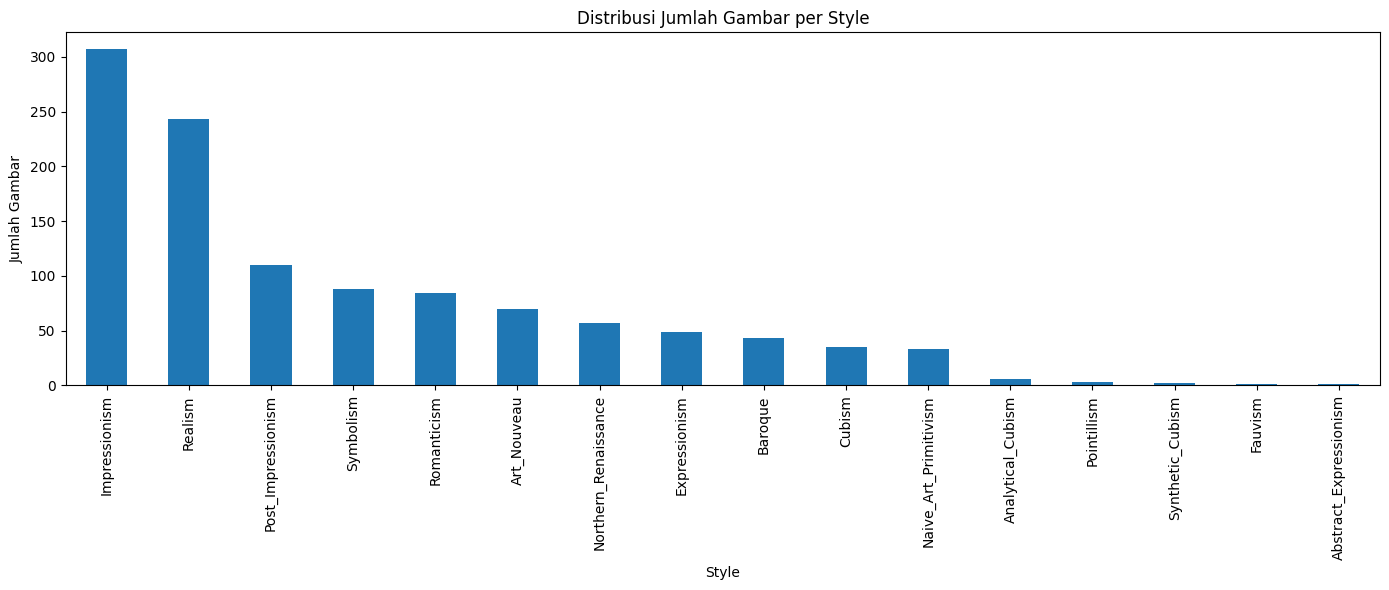

In [8]:
# distribusi per style
plt.figure(figsize=(14, 6))
style_counts.plot(kind='bar')
plt.title("Distribusi Jumlah Gambar per Style")
plt.xlabel("Style"); plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=90); plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_distribusi_style.png")); plt.show()

**Analisis:** Grafik menunjukkan dominasi kuat Impressionism dan Realism (bersama menyumbang ~49% dari seluruh data), sementara mayoritas kelas lain berada jauh di bawah 100 sample. Pola *long-tail* seperti ini umum di dataset seni rupa, tapi berisiko membuat model bias memprediksi kelas mayoritas — perlu ditangani lewat weighted sampling atau exclude kelas minoritas saat training.

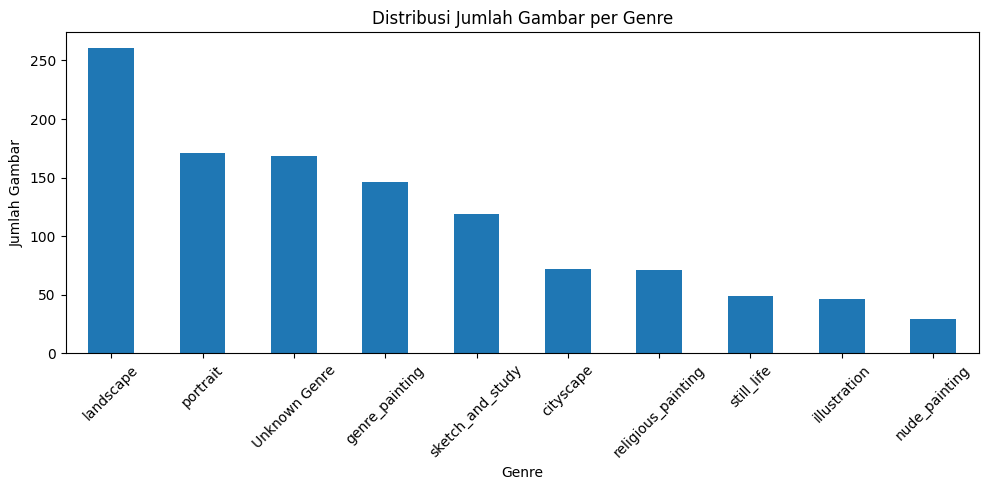

In [9]:
# distribusi per genre
plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar')
plt.title("Distribusi Jumlah Gambar per Genre")
plt.xlabel("Genre"); plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_distribusi_genre.png")); plt.show()

**Analisis:** *Landscape* mendominasi (261 gambar), diikuti *portrait* dan *Unknown Genre* (168 — cukup besar, menandakan ada porsi data tanpa label genre yang jelas dari sumber aslinya). Imbalance di genre jauh lebih ringan (9x) dibanding style (307x), sehingga genre bisa jadi label alternatif yang lebih stabil untuk task klasifikasi jika imbalance style menyulitkan training.

=== Statistik Ukuran Gambar ===
             width       height  aspect_ratio
count  1132.000000  1132.000000   1132.000000
mean   1672.890459  1619.732332      1.092301
std     366.262955   330.769464      0.375269
min     750.000000   597.000000      0.349078
25%    1382.000000  1382.000000      0.761013
50%    1551.000000  1382.000000      1.123010
75%    1883.000000  1816.000000      1.362518
max    4531.000000  3959.000000      3.278582


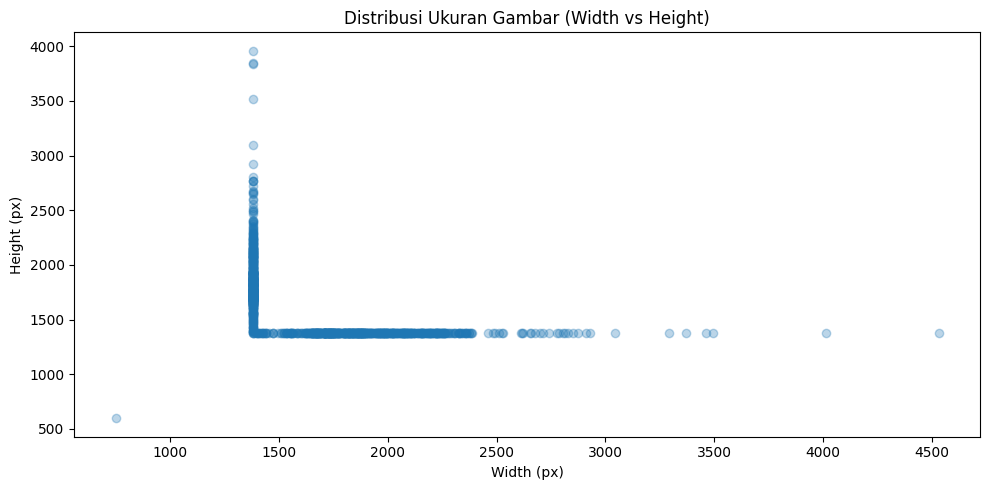

In [10]:
# distribusi ukuran gambar
sizes = [Image.open(os.path.join(output_dir, f)).size for f in meta_df['filename']]
size_df = pd.DataFrame(sizes, columns=['width', 'height'])
size_df['aspect_ratio'] = size_df['width'] / size_df['height']

print("=== Statistik Ukuran Gambar ===")
print(size_df.describe())

plt.figure(figsize=(10, 5))
plt.scatter(size_df['width'], size_df['height'], alpha=0.3)
plt.title("Distribusi Ukuran Gambar (Width vs Height)")
plt.xlabel("Width (px)"); plt.ylabel("Height (px)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_distribusi_ukuran.png")); plt.show()

**Analisis:** Ukuran gambar bervariasi cukup lebar (750–4531px lebar, 597–3959px tinggi), rata-rata ~1670×1620px — jauh di atas ukuran input standar CNN (224×224). Semua gambar wajib di-resize sebelum training. Sebaran titik pada scatter plot cukup menyebar tanpa cluster ukuran yang aneh, menandakan tidak ada anomali ukuran ekstrem yang perlu dibuang.

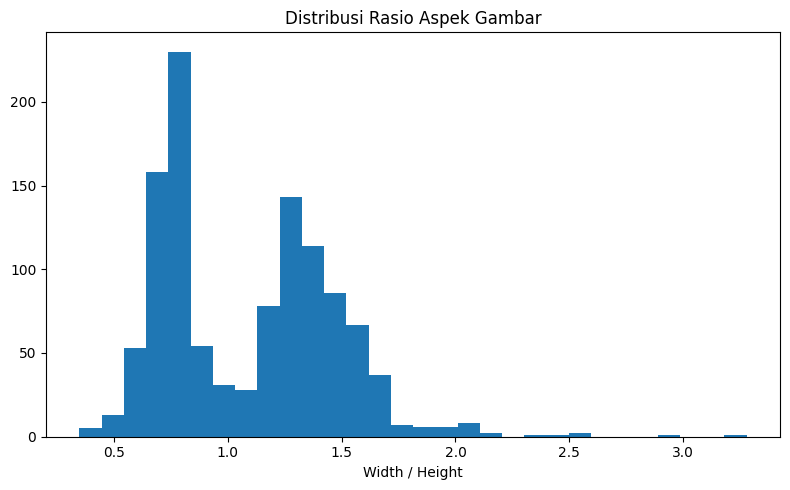

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(size_df['aspect_ratio'], bins=30)
plt.title("Distribusi Rasio Aspek Gambar")
plt.xlabel("Width / Height")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_aspect_ratio.png")); plt.show()

**Analisis:** Rata-rata rasio aspek 1.09 (mendekati persegi), dengan rentang 0.35–3.28 — artinya campuran orientasi potret dan lanskap. Ini perlu diperhatikan saat resize/crop: `RandomCrop` setelah `Resize` proporsional lebih aman dipakai dibanding force-resize ke rasio persegi, supaya komposisi lukisan tidak terdistorsi.

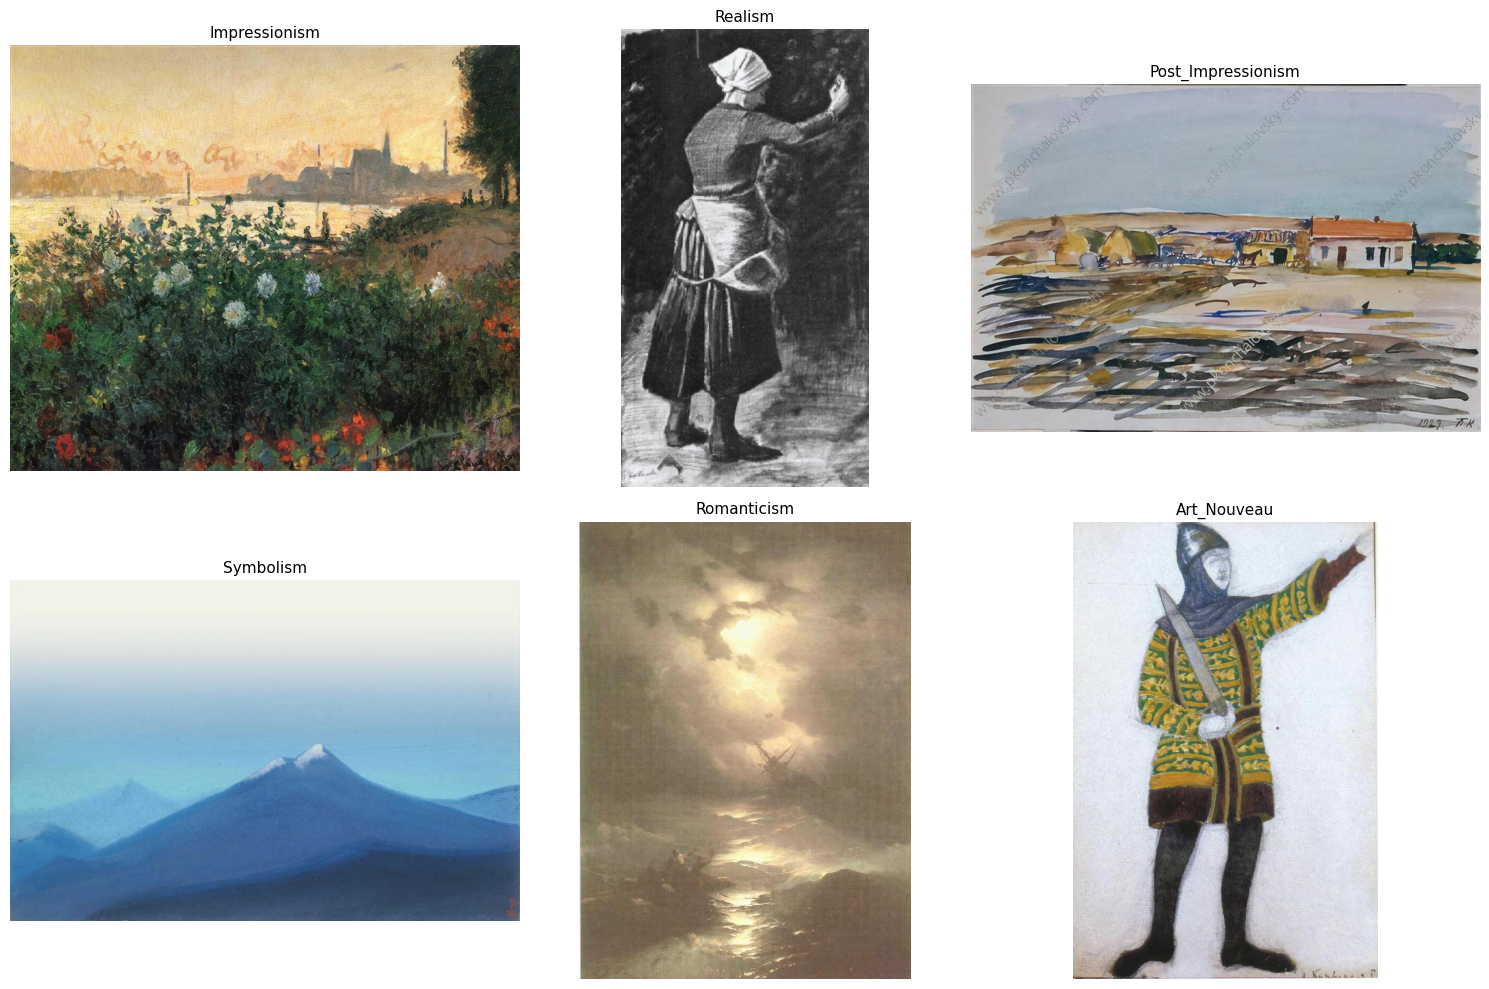

In [12]:
# sample gambar per style teratas
top_styles = style_counts.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, style in zip(axes.flatten(), top_styles):
    row = meta_df[meta_df['style_name'] == style].sample(1, random_state=42).iloc[0]
    img = Image.open(os.path.join(output_dir, row['filename']))
    ax.imshow(img); ax.set_title(style, fontsize=11); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_sample_per_style.png")); plt.show()

**Analisis:** Sample visual dari 6 style teratas menunjukkan perbedaan gaya yang cukup kontras (warna, sapuan kuas, komposisi) — indikasi baik bahwa fitur visual yang ditangkap CNN nantinya cukup diskriminatif antar kelas mayoritas ini.

## 4. Representativeness Check (Shard Pertama vs Keseluruhan Dataset)

In [13]:
print("=== Top 20 Artist (cek apakah data 'berkelompok' / tidak random) ===")
print(artist_counts.head(20))

=== Top 20 Artist (cek apakah data 'berkelompok' / tidak random) ===
artist_name
vincent-van-gogh         125
nicholas-roerich         119
claude-monet              80
pierre-auguste-renoir     70
pyotr-konchalovsky        67
albrecht-durer            50
pablo-picasso             49
gustave-dore              47
camille-pissarro          46
boris-kustodiev           46
john-singer-sargent       43
rembrandt                 43
ilya-repin                37
marc-chagall              37
martiros-saryan           36
ivan-aivazovsky           34
edgar-degas               34
childe-hassam             33
paul-cezanne              29
salvador-dali             27
Name: count, dtype: int64


**Analisis:** Subset didominasi artist tertentu (Van Gogh 125, Roerich 119, Monet 80) dari total hanya 24 artist — jauh dari 129 artist di WikiArt penuh. Ini mengonfirmasi subset **bukan random sample**, melainkan berurutan sesuai shard pertama dataset asli. **Wajib dicatat sebagai limitation di Data Card**: hasil EDA dan model yang dilatih dari subset ini belum tentu representatif terhadap keseluruhan populasi WikiArt.

## 5. Konsistensi Mode Warna Gambar

In [14]:
modes = [Image.open(os.path.join(output_dir, f)).mode for f in meta_df['filename']]
print("=== Distribusi Mode Warna ===")
print(pd.Series(modes).value_counts())

=== Distribusi Mode Warna ===
RGB    1132
Name: count, dtype: int64


**Analisis:** 100% gambar dalam mode RGB, tidak ada campuran grayscale/CMYK. Tidak perlu penanganan konversi warna khusus sebelum masuk pipeline training.

## 6. Korelasi Antar Label (Artist vs Style)

In [15]:
style_per_artist = meta_df.groupby('artist_name')['style_name'].nunique()
print("=== Variasi Style per Artist ===")
print(style_per_artist.describe())
print(style_per_artist.sort_values(ascending=False).head(10))

=== Variasi Style per Artist ===
count    24.000000
mean      2.541667
std       2.146365
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       9.000000
Name: style_name, dtype: float64
artist_name
pablo-picasso          9
salvador-dali          7
martiros-saryan        6
pyotr-konchalovsky     4
paul-cezanne           4
marc-chagall           3
boris-kustodiev        3
camille-pissarro       3
nicholas-roerich       3
john-singer-sargent    2
Name: style_name, dtype: int64


**Analisis:** Rata-rata 1 artist memiliki ~2.5 style berbeda (Picasso paling variatif dengan 9 style). Ini menunjukkan label *artist* dan *style* tidak sepenuhnya redundan — keduanya membawa informasi yang berbeda, sehingga keputusan memakai *style* sebagai label utama untuk Visual Search (bukan artist) tetap relevan dan tidak kehilangan sinyal penting.

## 7. Outlier Visual (Brightness Ekstrem)

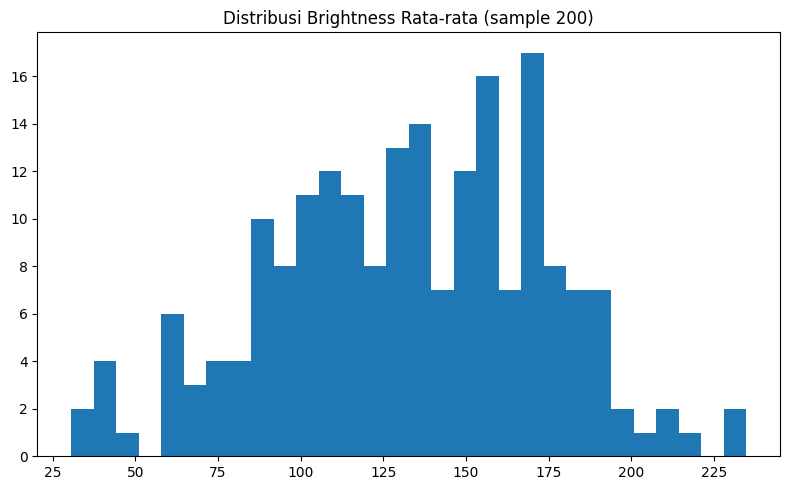

Gambar brightness ekstrem (<10 atau >245): 0


In [16]:
brightness_scores = []
for f in meta_df['filename'][:200]:
    img = Image.open(os.path.join(output_dir, f)).convert('L')
    brightness_scores.append(np.array(img).mean())

plt.figure(figsize=(8, 5))
plt.hist(brightness_scores, bins=30)
plt.title("Distribusi Brightness Rata-rata (sample 200)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_brightness.png")); plt.show()

n_outlier = sum(1 for b in brightness_scores if b < 10 or b > 245)
print(f"Gambar brightness ekstrem (<10 atau >245): {n_outlier}")

**Analisis:** Dari 200 sample yang dicek, tidak ada satupun gambar dengan brightness ekstrem (<10 atau >245). Tidak ada indikasi gambar rusak/hasil crawling error (misal gambar hitam/putih polos) di dalam subset ini.

## 8. Stratified Train/Val/Test Split (Exclude Kelas Minoritas)

In [17]:
MIN_SAMPLES = 6
valid_styles = style_counts[style_counts >= MIN_SAMPLES].index
meta_df_filtered = meta_df[meta_df['style_name'].isin(valid_styles)].copy()

print(f"Sebelum filter: {len(meta_df)} gambar, {meta_df['style_name'].nunique()} kelas style")
print(f"Setelah filter: {len(meta_df_filtered)} gambar, {meta_df_filtered['style_name'].nunique()} kelas style")

train_df, temp_df = train_test_split(
    meta_df_filtered, test_size=0.3, stratify=meta_df_filtered['style_name'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['style_name'], random_state=42
)

print(f"Train: {len(train_df)} ({len(train_df)/len(meta_df_filtered)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(meta_df_filtered)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(meta_df_filtered)*100:.1f}%)")

train_df.to_csv(os.path.join(output_dir, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test_split.csv"), index=False)

print("Semua file EDA (.png) dan split (.csv) tersimpan di:", output_dir)

Sebelum filter: 1132 gambar, 16 kelas style
Setelah filter: 1125 gambar, 12 kelas style
Train: 787 (70.0%)
Val:   169 (15.0%)
Test:  169 (15.0%)
Semua file EDA (.png) dan split (.csv) tersimpan di: C:\wikiart_sample


**Analisis:** Setelah exclude 4 kelas minoritas (1132→1125 gambar, 16→12 kelas style), stratified split berhasil dilakukan tanpa error: Train 787 (70%), Val 169 (15%), Test 169 (15%) — proporsi kelas per style terjaga konsisten di ketiga subset, siap dipakai untuk tahap fine-tuning model CNN pada iterasi berikutnya.

## 8b. Kenapa 4 Kelas Style Dihapus (justifikasi visual)

Filter `MIN_SAMPLES = 6` membuang 4 kelas: **Pointillism (3), Synthetic_Cubism (2),
Fauvism (1), Abstract_Expressionism (1)**. Bukan pilihan estetis — ada alasan teknis:

1. **Stratified split mustahil** kalau ada kelas < 2 sampel (`train_test_split` langsung `ValueError`).
2. Kelas 3-5 sampel: porsi val/test (~15%) membulat ke **0** → tak terwakili saat evaluasi.
3. 1-5 gambar terlalu sedikit untuk CNN belajar → hanya jadi noise & menyeret macro-F1.

*(Sel di bawah mandiri — baca langsung dari `data/raw/`, tak perlu jalankan sel atas.)*

In [ ]:
# ALASAN 1: stratified split GAGAL bila kelas minoritas tidak dibuang
import pandas as pd
from pathlib import Path
def _find_raw():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("data/raw", "ml/data/raw"):
            if (base / rel / "metadata.csv").is_file():
                return base / rel
    raise FileNotFoundError("Folder data/raw tak ketemu")
_RAW = _find_raw()
_OUT = _RAW.parent.parent / "outputs"; _OUT.mkdir(exist_ok=True)
from sklearn.model_selection import train_test_split

_meta = pd.read_csv(_RAW / "metadata.csv")
try:
    train_test_split(_meta, test_size=0.3, stratify=_meta["style_name"], random_state=42)
    print("(tidak error)")
except ValueError as e:
    print("train_test_split(stratify='style_name') tanpa membuang kelas kecil:")
    print("  ->", e)

In [ ]:
# Visualisasi: ambang MIN_SAMPLES + konsekuensinya untuk kelas kecil
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
def _find_raw():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("data/raw", "ml/data/raw"):
            if (base / rel / "metadata.csv").is_file():
                return base / rel
    raise FileNotFoundError("Folder data/raw tak ketemu")
_RAW = _find_raw()
_OUT = _RAW.parent.parent / "outputs"; _OUT.mkdir(exist_ok=True)

MIN_SAMPLES = 6
sc = pd.read_csv(_RAW / "metadata.csv")["style_name"].value_counts().sort_values()  # 16 kelas

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

colors = ["#d62728" if v < MIN_SAMPLES else "#4c9f4c" for v in sc.values]
ax[0].barh(sc.index, sc.values, color=colors)
ax[0].axvline(MIN_SAMPLES, ls="--", c="k", lw=1)
ax[0].set_xscale("log"); ax[0].set_xlim(0.7, 500)
for i, v in enumerate(sc.values):
    ax[0].text(v * 1.15, i, str(v), va="center", fontsize=9)
ax[0].set_title(f"16 style di subset  (merah = < {MIN_SAMPLES} sampel -> dihapus)")
ax[0].set_xlabel("jumlah gambar (skala log)")

small = sc[sc <= 12]
sim = pd.DataFrame({
    "train ~70%": np.floor(small.values * 0.70).astype(int),
    "val ~15%":   np.round(small.values * 0.15).astype(int),
    "test ~15%":  np.round(small.values * 0.15).astype(int),
}, index=small.index)
sim.plot(kind="barh", stacked=True, ax=ax[1], color=["#1f77b4", "#ff7f0e", "#8c8c8c"])
for i, (_, row) in enumerate(sim.iterrows()):
    zero = (row["val ~15%"] == 0) or (row["test ~15%"] == 0)
    ax[1].text(row.sum() + 0.2, i, f"val={row['val ~15%']}, test={row['test ~15%']}",
               va="center", fontsize=8, color="#d62728" if zero else "#333")
ax[1].set_title("Perkiraan stratified split 70/15/15\nkelas < 6: val/test jatuh ke 0")
ax[1].set_xlabel("jumlah gambar")

fig.suptitle("Kenapa Pointillism, Synthetic_Cubism, Fauvism, Abstract_Expressionism dihapus",
             fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(_OUT / "eda_kenapa_hapus_4_kelas.png", dpi=110)
plt.show()

## 9. Penanganan Class Imbalance

Setelah filter, **12 kelas** tetap sangat timpang di *training set*:
Impressionism **215** vs Analytical_Cubism **4** → rasio **~54×**.

Strategi (diterapkan di `ml/src/`):

| Cara | Di mana | Efek |
|---|---|---|
| **WeightedRandomSampler** (inverse-frekuensi) | `dataset.py` | tiap epoch, kelas langka lebih sering diambil → distribusi efektif ~seimbang |
| **macro-F1** sebagai metrik best-model | `train.py` / `config.yaml` | accuracy bias ke kelas mayoritas; macro-F1 menghukum kelas terabaikan |
| **label smoothing 0.1** | `train.py` | model tidak overconfident ke kelas mayoritas |
| Augmentasi (flip, rotation, color jitter) | `transforms.py` | variasi efektif untuk kelas kecil |
| Fine-tune `layer4` + `fc` saja | `model.py` | parameter sedikit → overfit ke kelas besar berkurang |

Di bawah: bukti efek WeightedRandomSampler.

In [ ]:
# Hitung bobot inverse-frekuensi & simulasikan 1 epoch sampling.
# Setara torch.utils.data.WeightedRandomSampler(replacement=True) yang dipakai
# di ml/src/dataset.py -- di sini numpy saja supaya notebook EDA tak butuh torch.
import numpy as np, pandas as pd
from pathlib import Path

def _find_raw():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("data/raw", "ml/data/raw"):
            if (base / rel / "metadata.csv").is_file():
                return base / rel
    raise FileNotFoundError("Folder data/raw tak ketemu")
_RAW = _find_raw()

train_df = pd.read_csv(_RAW / "train_split.csv")
classes = sorted(train_df["style_name"].unique())          # urutan = ml/src/dataset.py
y = train_df["style_name"].map({c: i for i, c in enumerate(classes)}).to_numpy()

count = np.bincount(y, minlength=len(classes))
weight_per_class = 1.0 / count
weight_per_sample = weight_per_class[y]

# multinomial sampling dengan replacement (identik WeightedRandomSampler)
rng = np.random.default_rng(42)
prob = weight_per_sample / weight_per_sample.sum()
drawn = rng.choice(len(y), size=len(y), replace=True, p=prob)
count_after = np.bincount(y[drawn], minlength=len(classes))

print(pd.DataFrame({
    "train asli": count,
    "bobot / kelas": weight_per_class.round(4),
    "setelah sampler (1 epoch)": count_after,
}, index=classes))
print(f"\nrasio max/min   asli {count.max() / count.min():.1f}x"
      f"   ->   setelah sampler {count_after.max() / count_after.min():.2f}x")

In [ ]:
# Plot: distribusi kelas sebelum vs sesudah sampler + bobot per kelas
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
def _find_raw():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("data/raw", "ml/data/raw"):
            if (base / rel / "metadata.csv").is_file():
                return base / rel
    raise FileNotFoundError("Folder data/raw tak ketemu")
_RAW = _find_raw()
_OUT = _RAW.parent.parent / "outputs"; _OUT.mkdir(exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(classes))

ax[0].bar(x - 0.2, count, width=0.4, label="asli (train)", color="#d62728")
ax[0].bar(x + 0.2, count_after, width=0.4, label="setelah WeightedRandomSampler", color="#4c9f4c")
ax[0].set_xticks(x); ax[0].set_xticklabels(classes, rotation=90)
ax[0].set_ylabel("jumlah sampel per epoch"); ax[0].legend()
ax[0].set_title(f"Distribusi kelas: {count.max() / count.min():.0f}x  ->  "
                f"{count_after.max() / count_after.min():.1f}x")

ax[1].bar(x, weight_per_class, color="#1f77b4")
ax[1].set_xticks(x); ax[1].set_xticklabels(classes, rotation=90)
ax[1].set_title("Bobot sampling per kelas = 1 / frekuensi")
ax[1].set_ylabel("bobot (relatif)")

fig.suptitle("WeightedRandomSampler - kelas langka diambil lebih sering",
             fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(_OUT / "eda_handle_imbalance.png", dpi=110)
plt.show()

**Catatan jujur (untuk laporan):** WeightedRandomSampler menyeimbangkan *frekuensi
kemunculan*, bukan menambah *informasi*. Analytical_Cubism tetap hanya 4 gambar unik —
model melihat gambar yang sama berulang, jadi F1 kelas ini kemungkinan tetap rendah.
Ini keterbatasan data (bukan bug) dan dicatat di Data Card. Mitigasi paling efektif
kalau hasil kurang memadai: **menambah shard WikiArt**.

## 10. Augmentasi Data Training (kode + visualisasi + bukti)

Kode augmentasi **asli** ada di `ml/src/transforms.py` dan dipakai persis oleh
`01_train.ipynb` / `python -m src.train`. Di sel 10.1 kode itu ditampilkan
sebagai teks (dibaca dari file, tanpa import).

Visualisasi di bawah memakai **PIL** (operasi setara) supaya jalan di kernel
EDA tanpa `torch`/`torchvision`. Pipeline torchvision yang sebenarnya:
`Resize(256) -> RandomCrop(224) -> RandomHorizontalFlip(0.5) -> TrivialAugmentWide -> Normalize`.

- Augmentasi HANYA pada split **train**. val/test/embedding = deterministik.
- Saat evaluasi ada **TTA** (rata-rata prediksi asli + horizontal-flip).
- **Tanpa** vertical flip / cutout (CLAUDE.md: merusak komposisi & detail gaya).

In [ ]:
# 10.1 — kode augmentasi ASLI (dibaca dari src/transforms.py, tanpa import torch)
from pathlib import Path
_p = Path.cwd()
while not ((_p / "src").is_dir() and (_p / "configs").is_dir()):
    if _p == _p.parent:
        raise RuntimeError("folder ml/ tidak ketemu dari " + str(Path.cwd()))
    _p = _p.parent
print((_p / "src" / "transforms.py").read_text(encoding="utf-8"))

In [ ]:
# 10.2 — helper augmentasi versi PIL (setara pipeline train)
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps

RAW, PROC, OUT = _p / "data/raw", _p / "data/processed", _p / "outputs"
WHITE = (255, 255, 255)

def center_crop(img, s=224):
    w, h = img.size; l, t = (w - s) // 2, (h - s) // 2
    return img.crop((l, t, l + s, t + s))

def random_crop(img, s=224):
    w, h = img.size
    x, y = random.randint(0, max(0, w - s)), random.randint(0, max(0, h - s))
    return img.crop((x, y, x + s, y + s))

def hflip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

# operasi ala TrivialAugmentWide (satu dipilih acak, magnitudo acak)
_OPS = [
    ("Brightness",   lambda im, m: ImageEnhance.Brightness(im).enhance(1 + m)),
    ("Contrast",     lambda im, m: ImageEnhance.Contrast(im).enhance(1 + m)),
    ("Color",        lambda im, m: ImageEnhance.Color(im).enhance(1 + m)),
    ("Sharpness",    lambda im, m: ImageEnhance.Sharpness(im).enhance(1 + 2 * m)),
    ("Rotate",       lambda im, m: im.rotate(30 * m, resample=Image.BILINEAR, fillcolor=WHITE)),
    ("ShearX",       lambda im, m: im.transform(im.size, Image.AFFINE, (1, m, 0, 0, 1, 0), fillcolor=WHITE)),
    ("TranslateX",   lambda im, m: im.transform(im.size, Image.AFFINE, (1, 0, m * im.size[0] * 0.3, 0, 1, 0), fillcolor=WHITE)),
    ("Posterize",    lambda im, m: ImageOps.posterize(im, max(2, int(8 - 4 * abs(m))))),
    ("Solarize",     lambda im, m: ImageOps.solarize(im, int(255 - 128 * abs(m)))),
    ("AutoContrast", lambda im, m: ImageOps.autocontrast(im)),
    ("Equalize",     lambda im, m: ImageOps.equalize(im)),
]

def trivial_like(img):
    name, fn = random.choice(_OPS)
    return fn(img, random.uniform(-0.6, 0.6)), name

def train_aug(img256):
    # tiruan PIL dari build_train_transforms
    im = random_crop(img256, 224)
    if random.random() < 0.5:
        im = hflip(im)
    im, _ = trivial_like(im)
    return im

meta = pd.read_csv(RAW / "metadata.csv")
picks = meta.drop_duplicates("style_name").head(4)[["filename", "style_name"]].values.tolist()
print("contoh:", picks)

### 10a. Bukti: 1 gambar -> banyak hasil augmentasi berbeda

In [ ]:
random.seed(0)
fig, axes = plt.subplots(len(picks), 7, figsize=(17, 2.6 * len(picks)))
for r, (fn, style) in enumerate(picks):
    src = Image.open(PROC / fn).convert("RGB")     # sudah SquarePad + resize 256 (src.preprocess)
    axes[r, 0].imshow(center_crop(src)); axes[r, 0].set_title(f"input model\n{style}", fontsize=8)
    axes[r, 0].axis("off")
    for c in range(1, 7):
        axes[r, c].imshow(train_aug(src)); axes[r, c].set_title(f"train aug #{c}", fontsize=8)
        axes[r, c].axis("off")
fig.suptitle("Kolom 1 = gambar deterministik yang dilihat model saat eval. "
             "Kolom 2-7 = 6 augmentasi acak dari gambar yang SAMA", fontsize=11)
fig.tight_layout(); fig.savefig(OUT / "aug_variasi.png", dpi=110); plt.show()

### 10b. Efek tiap operasi augmentasi terpisah

In [ ]:
random.seed(1)
img = Image.open(PROC / picks[0][0]).convert("RGB").resize((224, 224))
demos = [
    ("asli", img),
    ("HorizontalFlip", hflip(img)),
    ("Rotate +15 deg", img.rotate(15, resample=Image.BILINEAR, fillcolor=WHITE)),
    ("Rotate -15 deg", img.rotate(-15, resample=Image.BILINEAR, fillcolor=WHITE)),
    ("Brightness x1.4", ImageEnhance.Brightness(img).enhance(1.4)),
    ("Contrast x1.4", ImageEnhance.Contrast(img).enhance(1.4)),
    ("Color x0.4", ImageEnhance.Color(img).enhance(0.4)),
    ("RandomCrop", random_crop(img.resize((256, 256)), 224)),
    ("Equalize", ImageOps.equalize(img)),
    ("Solarize", ImageOps.solarize(img, 128)),
]
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, (name, im) in zip(axes.flat, demos):
    ax.imshow(im); ax.set_title(name, fontsize=9); ax.axis("off")
fig.suptitle("Efek tiap operasi (ilustrasi PIL). Pipeline train pakai kombinasi acak lewat TrivialAugmentWide",
             fontsize=12)
fig.tight_layout(); fig.savefig(OUT / "aug_per_operasi.png", dpi=110); plt.show()

### 10c. Bukti: EVAL tidak diaugmentasi, TRAIN diaugmentasi

In [ ]:
random.seed(2)
src = Image.open(PROC / picks[1][0]).convert("RGB")
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for c in range(6):
    axes[0, c].imshow(center_crop(src))   # eval: sama tiap kali
    axes[1, c].imshow(train_aug(src))     # train: beda tiap kali
    for r in (0, 1):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_ylabel("EVAL\n(deterministik)", fontsize=10)
axes[1, 0].set_ylabel("TRAIN\n(augmentasi)", fontsize=10)
fig.suptitle("EVAL: 6x transform -> IDENTIK.   TRAIN: 6x transform -> beda semua.", fontsize=11)
fig.tight_layout(); fig.savefig(OUT / "aug_train_vs_eval.png", dpi=110); plt.show()

### 10d. Ringkasan

| Langkah | Train | Val / Test / Embedding |
|---|---|---|
| SquarePad + resize 256 (via `src.preprocess`) | Ya | Ya |
| RandomCrop 224 | Ya | Tidak (CenterCrop) |
| RandomHorizontalFlip 0.5 | Ya | Tidak |
| TrivialAugmentWide | Ya | Tidak |
| Normalisasi ImageNet | Ya | Ya |
| TTA (asli + hflip) saat inferensi | - | Ya (evaluasi) |

- **Vertical flip & cutout TIDAK dipakai** (CLAUDE.md).
- Kode asli: `ml/src/transforms.py` -> `build_train_transforms` / `build_eval_transforms`
  (tercetak lengkap di sel 10.1). Config: `configs/config.yaml` bagian `augmentation`.
- Visualisasi di atas pakai PIL (kernel EDA tanpa torch); operasinya setara pipeline torchvision.
- PNG di `ml/outputs/aug_*.png`.